## Week 2 · Testing an object detector  🧪

We trained a model in `train.ipynb`; now we **evaluate** it on a set of test sequences it has never seen. Testing tells us how well the detector performs.

**Quantitative results.** The standard metric for object detection is the **mean Average Precision (mAP)**. Try to make some research about this metric and be sure to understand how it works.

**Qualitative results.** We draw the predicted boxes (with their confidence scores) on a few images and judge them with our own eyes.

We reuse the exact same **utils** and **data generator** as in training, so the model sees the images the same way it did while learning.

### Imports

In [66]:
import os
import random
import numpy as np
import xml.etree.ElementTree as ET
from typing import Tuple, Union, Any

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import detection
import torchvision.transforms.v2 as transforms
from torchmetrics.detection.mean_ap import MeanAveragePrecision

from torchvision.io import read_image, ImageReadMode
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

### Utils functions
Helper functions used throughout the notebook. Read the short docstrings to understand what each one does.

In [67]:
def new_history() -> dict:
    """Empty training history: losses per epoch, best validation loss and last finished epoch."""
    return {'train_loss': [], 'valid_loss': [], 'lr': [], 'best_value': np.inf, 'current_epoch': 0}


def set_seed(seed: int) -> None:
    """Fix every random source (Python, NumPy, PyTorch) so that runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def torch_load_cpu(path: str) -> Any:
    """Load a checkpoint onto the CPU."""
    return torch.load(path, map_location='cpu')


def load_checkpoint(path: str, model: Any, device: torch.device, optimizer: torch.optim = None) -> Tuple[Any, Any, dict]:
    """Load model weights, optimizer and RNG state from a checkpoint (to resume training or to test)."""
    checkpoint = torch_load_cpu(path)

    # Model weights
    model.load_state_dict({**model.state_dict(), **checkpoint.get('model', {})})

    # Random-number-generator state (single device: no multi-GPU here)
    if 'rng_state' in checkpoint:
        torch.set_rng_state(checkpoint['rng_state'])
    if torch.cuda.is_available() and checkpoint.get('cuda_rng_state') is not None:
        torch.cuda.set_rng_state(checkpoint['cuda_rng_state'])
    if 'numpy_rng_state' in checkpoint:
        np.random.set_state(checkpoint['numpy_rng_state'])
    if 'python_rng_state' in checkpoint:
        random.setstate(checkpoint['python_rng_state'])

    # Optimizer state (only needed to resume training)
    if optimizer is not None and 'optimizer' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer'])
        for state in optimizer.state.values():
            for k, v in state.items():
                if torch.is_tensor(v):
                    state[k] = v.to(device)

    history = checkpoint.get('history', new_history())
    return model, optimizer, history


def save_checkpoint(path: str, model: Any, optimizer: torch.optim, lr_scheduler: Any, history: dict) -> None:
    """Save everything needed to resume training later (and to test the model afterwards)."""
    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'lr_scheduler': lr_scheduler.state_dict(),
        'history': history,
        'rng_state': torch.get_rng_state(),
        'cuda_rng_state': torch.cuda.get_rng_state() if torch.cuda.is_available() else None,
        'numpy_rng_state': np.random.get_state(),
        'python_rng_state': random.getstate(),
    }, path)


def torchvision_model(model_name: str, pretrained: bool = False, num_classes: int = 2) -> Any:
    """Build a torchvision detection model and adapt its head to `num_classes` (0=background, 1=object)."""
    model_dict = {
        'faster_rcnn_v1': detection.fasterrcnn_resnet50_fpn,
        'faster_rcnn_v2': detection.fasterrcnn_resnet50_fpn_v2,
        'faster_rcnn_v3': detection.fasterrcnn_mobilenet_v3_large_fpn,
        'retinanet_v1': detection.retinanet_resnet50_fpn,
        'retinanet_v2': detection.retinanet_resnet50_fpn_v2,
        'ssd_v1': detection.ssd300_vgg16,
        'ssd_v2': detection.ssdlite320_mobilenet_v3_large,
    }
    assert model_name in model_dict, f"Unknown model '{model_name}'. Choose one of: {list(model_dict)}"

    # Load the architecture (optionally with COCO pre-trained weights)
    model = model_dict[model_name](weights='COCO_V1' if pretrained else None)

    # Replace the classification head so it predicts our number of classes
    if 'faster_rcnn' in model_name:
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    elif 'retinanet' in model_name:
        in_features = model.head.classification_head.cls_logits.in_channels
        num_anchors = model.head.classification_head.num_anchors
        model.head.classification_head = detection.retinanet.RetinaNetClassificationHead(in_features, num_anchors, num_classes)
    elif model_name == 'ssd_v1':
        in_features = [module.in_channels for module in model.head.classification_head.module_list]
        num_anchors = model.anchor_generator.num_anchors_per_location()
        model.head.classification_head = detection.ssd.SSDClassificationHead(in_features, num_anchors, num_classes)
    elif model_name == 'ssd_v2':
        in_features = [module[0][0].in_channels for module in model.head.classification_head.module_list]
        num_anchors = model.anchor_generator.num_anchors_per_location()
        model.head.classification_head = detection.ssd.SSDClassificationHead(in_features, num_anchors, num_classes)
    return model


def get_model(model_name: str, model_path: str = '', num_classes: int = 2, lr_data: list = None,
              pretrained: bool = False, use_gpu: bool = False) -> Tuple[Any, Any, dict, torch.device]:
    """Create the model (and optimizer) and, if a checkpoint exists at `model_path`, resume from it."""
    device = torch.device('cuda' if use_gpu and torch.cuda.is_available() else 'cpu')
    model = torchvision_model(model_name, pretrained, num_classes).to(device)

    # Optimizer
    if lr_data:
        params = [p for p in model.parameters() if p.requires_grad]
        optimizer = torch.optim.SGD(params, lr=lr_data[0], momentum=lr_data[1], weight_decay=lr_data[2])
    else:
        optimizer = None

    # Resume from a checkpoint if one is found
    if os.path.isfile(model_path):
        model, optimizer, history = load_checkpoint(model_path, model, device, optimizer)
        print(f"Resumed from '{model_path}' (epoch {history['current_epoch']}).")
    else:
        history = new_history()
        print(f"No checkpoint at '{model_path}'. Starting from scratch.")
    return model, optimizer, history, device


def clip_grad_norms(param_groups, max_norm: float = 0) -> None:
    """Clip gradient norms to avoid exploding gradients (max_norm=0 disables clipping)."""
    if max_norm <= 0:
        return
    for group in param_groups:
        torch.nn.utils.clip_grad_norm_(group['params'], max_norm, norm_type=2)

### Data Generator
A *Dataset* loads one image with its annotations at a time; a *DataLoader* groups several of them into a batch to feed the network during train, validation and test.

In [68]:
class CustomDataset(Dataset):
    """Feeds images and their bounding-box annotations to the network."""

    def __init__(self, path_dataset: str, resize_shape: tuple = None, transform: transforms.Compose = None) -> None:
        print("Loading annotations...")
        self.annotations = parse_annotations(path_dataset)
        self.resize_shape = resize_shape
        self.transform = transform

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, dict]:
        annotation = self.annotations[idx]

        # Load the image and its boxes/labels
        image = read_image(annotation['path_image'], ImageReadMode.RGB)
        boxes = torch.as_tensor(annotation['boxes'], dtype=torch.float32).reshape(-1, 4)
        labels = torch.as_tensor(annotation['labels'], dtype=torch.int64)

        # Pre-process the image
        if self.transform:
            height, width = image.shape[-2:]
            image = self.transform(image)
            if self.resize_shape:
                boxes = resize_boxes(boxes, self.resize_shape, (height, width))

        # Torchvision detection models expect this structure
        return image, {'boxes': boxes, 'labels': labels}

    def __len__(self) -> int:
        return len(self.annotations)


def resize_boxes(boxes: torch.Tensor, resize_shape: tuple, image_shape: tuple) -> torch.Tensor:
    """Rescale [x_min, y_min, x_max, y_max] boxes when the image is resized (height, width)."""
    scale_h, scale_w = resize_shape[0] / image_shape[0], resize_shape[1] / image_shape[1]
    boxes[:, [0, 2]] *= scale_w
    boxes[:, [1, 3]] *= scale_h
    return boxes


def get_transform(resize_shape: Union[tuple, None] = None) -> transforms.Compose:
    """Turn an image into a float tensor in [0, 1]. Detection models normalise internally, so we do not normalise here."""
    t = [transforms.ToImage(), transforms.ToDtype(torch.float32, scale=True)]
    if resize_shape:
        t.append(transforms.Resize(resize_shape, antialias=True))
    return transforms.Compose(t)


def parse_annotations(path_dataset: str) -> list:
    """Read the dataset folder and return, per frame, the image path, its boxes and its labels."""
    annotations = []
    for sequence in tqdm(sorted(os.listdir(path_dataset))):
        labels_dir = os.path.join(path_dataset, sequence, 'labels')

        # Skip anything without a 'labels' folder
        if sequence.startswith('.') or not os.path.isdir(labels_dir):
            continue

        for frame in sorted(os.listdir(labels_dir)):
            label_path = os.path.join(labels_dir, frame)
            if not os.path.isfile(label_path):
                continue
            image_name, boxes = read_label(label_path)
            annotations.append({
                'path_image': os.path.join(path_dataset, sequence, 'images', image_name),
                'boxes': np.array(boxes, dtype=np.float32).reshape(-1, 4),
                'labels': np.array([1] * len(boxes), dtype=np.int64),  # 1 = object
            })
    return annotations


def read_label(xml_file: str) -> Tuple[str, list]:
    """Read a Pascal VOC XML file and return the image filename and its list of boxes."""
    root = ET.parse(xml_file).getroot()
    image_name = root.find('filename').text
    boxes = []
    for obj in root.iter('object'):
        box = obj.find('bndbox')
        xmin, ymin = int(box.find('xmin').text), int(box.find('ymin').text)
        xmax, ymax = int(box.find('xmax').text), int(box.find('ymax').text)
        boxes.append([xmin, ymin, xmax, ymax])
    return image_name, boxes


def collate_fn(batch: list) -> tuple:
    """Keep images and targets as tuples (they cannot be stacked: sizes and box counts differ)."""
    return tuple(zip(*batch))

### Parameters
Read each parameter, understand what it does, and play with them to get the best model.

In [69]:
# Seed for reproducibility (do NOT change it if you want identical results)
SEED = 0
set_seed(SEED)

In [70]:
# Data
local_path = '..'
path_data_test = f'{local_path}/data_test'             # Labelled test sequences

# Model
model_name = 'faster_rcnn_v1'                          # Torchvision model (see torchvision_model for the full list)
num_classes = 2                                        # ALWAYS 2: 0 = background, 1 = object
resize_shape = None                                    # (height, width) to resize images, or None to keep the original size
model_path = f'{local_path}/models/{model_name}/model_best.pt'   # Trained model to evaluate

# Evaluation
batch_size = 8                                         # Images per batch
score_threshold = 0.5                                  # Minimum confidence to draw a predicted box
num_workers = 0                                        # CPU processes loading data (0 means main process, fully reproducible)
use_gpu = True                                         # Use the GPU if available

### Test

In [71]:
# Load model
model, _, _, device = get_model(
    model_name=model_name,
    model_path=model_path,
    num_classes=num_classes,
    lr_data=None,
    pretrained=False,
    use_gpu=use_gpu,
)

Resumed from '../models/faster_rcnn_v1/model_best.pt' (epoch 29).


We build the test **Dataset** and its **DataLoader** with the same pre-processing used during training.

In [72]:
# Same pre-processing as in training
transform = get_transform(resize_shape)

# Test dataset and loader
test_set = CustomDataset(path_dataset=path_data_test, resize_shape=resize_shape, transform=transform)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False,
                         num_workers=num_workers, collate_fn=collate_fn)

Loading annotations...


100%|██████████| 13/13 [00:00<00:00, 822.46it/s]


### Quantitative results
We run the model over the whole test set and measure different variants of the **mean Average Precision (mAP)**. Make some research about this variants too.

In [73]:
# Run the model on every test image
model.eval()
predictions, ground_truths = [], []
with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Testing'):
        images = [image.to(device) for image in images]
        outputs = model(images)
        predictions.extend([{k: v.cpu() for k, v in output.items()} for output in outputs])
        ground_truths.extend(targets)

Testing: 100%|██████████| 90/90 [00:15<00:00,  6.00it/s]


In [74]:
# Mean Average Precision (mAP)
metric = MeanAveragePrecision()
metric.update(predictions, ground_truths)
results = metric.compute()

print(f"mAP:         {results['map']:.4f}")
print(f"mAP@0.50     {results['map_50']:.4f}")
print(f"mAP@0.75     {results['map_75']:.4f}")
print(f"mAP@Small:   {results['map_small']:.4f}")
print(f"mAP@Medium:  {results['map_medium']:.4f}")
print(f"mAP@Large:   {results['map_large']:.4f}")

mAP:         0.5451
mAP@0.50     0.9441
mAP@0.75     0.5678
mAP@Small:   0.3043
mAP@Medium:  0.4885
mAP@Large:   0.6027


### Qualitative results
Draw every predicted box with a confidence above `score_threshold`.

In [75]:
def plot_predictions(image, prediction, score_threshold=0.5):
    """Draw the predicted boxes (above score_threshold) and their scores on the image."""
    boxes = prediction['boxes'].detach().cpu().numpy()
    scores = prediction['scores'].detach().cpu().numpy()

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)
    ax.axis('off')
    for (x_min, y_min, x_max, y_max), score in zip(boxes, scores):
        if score < score_threshold:
            continue
        ax.add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                               linewidth=2, edgecolor='lime', facecolor='none'))
        ax.text(x_min, y_min - 5, f'{score:.2f}', color='white', fontsize=10,
                bbox=dict(facecolor='black', alpha=0.6, pad=1))
    plt.show()

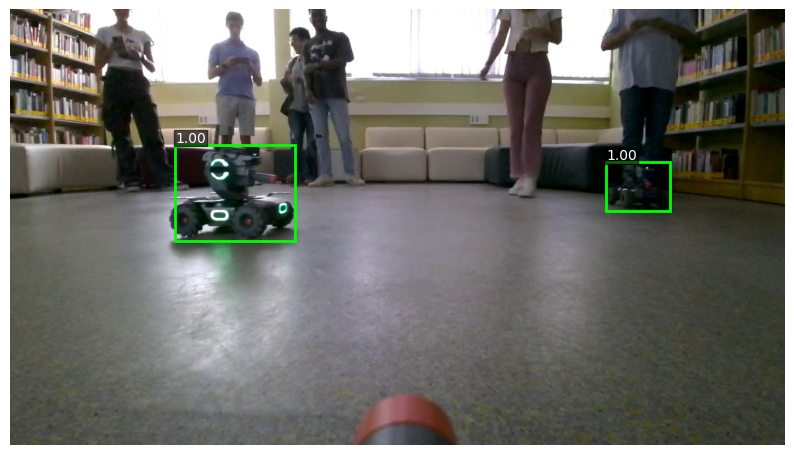

In [76]:
# Pick a test image (change the index to inspect a different one)
index = 0
image = plt.imread(test_set.annotations[index]['path_image'])

# Run the model on it and draw the predictions
model.eval()
with torch.no_grad():
    prediction = model([transform(image).to(device)])[0]

plot_predictions(image, prediction, score_threshold=score_threshold)